In [7]:
"""
CNNs with MNIST Dataset + Basic OCR

Goals:
Comparing an MLP with a CNN
Train a CNN
Apply the CNN to an OCR problem

"""

import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# We'll discuss these metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [8]:
"""
First step will be to load the MNIST Dataset
What is this data set?
60,000 Training images with Labels and 10,000 Test images with labels
What are the images? Handwritten Digits 0-9 (10 Classes)
Each image is a 28x28 image

Lets load the data and take a look at the shape of the inputs
"""

(X_train_raw, y_train), (X_test_raw, y_test) = tf.keras.datasets.mnist.load_data()

print("X_train_raw shape: ", X_train_raw.shape)
print("y_train shape: ", y_train.shape)
print("X_test_raw shape: ", X_test_raw.shape)
print("y_test shape: ", y_test.shape)
print("Pixel Range: ", X_train_raw.min(), "to", X_train_raw.max())

X_train_raw shape:  (60000, 28, 28)
y_train shape:  (60000,)
X_test_raw shape:  (10000, 28, 28)
y_test shape:  (10000,)
Pixel Range:  0 to 255


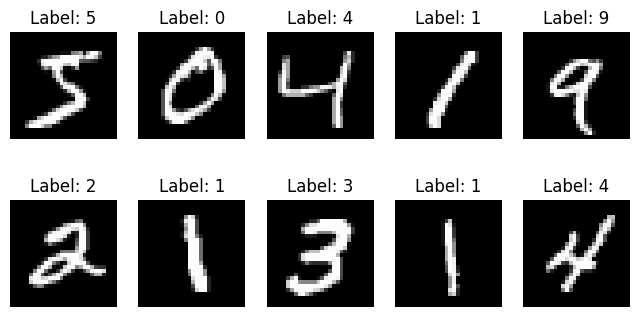

In [9]:
# Let's take a look at some of the data
plt.figure(figsize=(8, 4))
for i in range(10):
  plt.subplot(2, 5, i+1)
  plt.imshow(X_train_raw[i], cmap="gray")
  plt.title(f"Label: {y_train[i]}")
  plt.axis("off")
plt.show()

In [13]:
"""
We need to preprocess our data a little bit
Preprocessing for CNNs is important because they expect a channel value
Channels are color channels, so for normal images they have 3 (RGB), our case
we only have one

Additionally, to keep our weights in check, we'll scale this to 0-1 instead
of 0-255
"""

# Scale
# We could use a MinMaxScaler (converts to 0-1, useful for when you don't
# know the max)
# This also rescales since we know the pixels go from 0-255
X_train = X_train_raw.astype("float32") / 255.0
X_test = X_test_raw.astype("float32") / 255.0

# Reshape our image
# We need to change the shape from (60000, 28, 28) to (60000, 28, 28, 1)
# where 1 is the number of color channels
# Axis = -1 means add a dimension at the end
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

print("CNN Ready Shape for X_train: ", X_train.shape)
print("CNN Ready Shape for X_test", X_test.shape)
print("Pixel Range: ", X_train.min(), "to", X_train.max())

CNN Ready Shape for X_train:  (60000, 28, 28, 1)
CNN Ready Shape for X_test (10000, 28, 28, 1)
Pixel Range:  0.0 to 1.0


In [14]:
"""
Before we try a CNN, let's try to do this with a regular MLP
It can work and it might work in this case because the images are relatively easy
But you lose positional information and things can scale pretty quickly

We'll use a flatten layer to basically convert the entire input into a vector tensor
"""

dense_model = tf.keras.Sequential([
    # Input Layer
    tf.keras.layers.Input(shape=(28,28,1)),
    # Flatten
    tf.keras.layers.Flatten(),
    # Dense Layer
    tf.keras.layers.Dense(128, activation="relu"),
    # Output Layer (10 classes)
    tf.keras.layers.Dense(10, activation="softmax")
])

dense_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=.001),
    loss="sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

"""
What is Spare Categorical Entropy?
This is used for multi-class classification where the labels are integers (i.e 1-10)
How does this differ from regular Categorical Crossentropy?
Categorical Crossentropy is usually used with one-hot encoded vectors
[dog, cat, fish]
One hot encoded vector -> [0,1,0] -> cat is the one "hot" encoded

When to use each?
If you have one-hot vector labels, use regular Categorical Crossentropy
If you have integers (THIS IS OUR CASE), use Sparse Categorical Crossentropy
"""
dense_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
dense_history = dense_model.fit(
    X_train,
    y_train,
    validation_split = .1,
    epochs=3
)

Epoch 1/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9239 - loss: 0.2672 - val_accuracy: 0.9632 - val_loss: 0.1248
Epoch 2/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9648 - loss: 0.1164 - val_accuracy: 0.9705 - val_loss: 0.0994
Epoch 3/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9764 - loss: 0.0801 - val_accuracy: 0.9705 - val_loss: 0.0950


In [ ]:
"""
Our Dense model looks like it did pretty well for our images, remember they are
pretty simple, as we get to more complex shapes we'll need something a little
better, enter the Convolutional Neural Network
"""